# Step 5 — Analise de Resultados da Classificacao CNN (RNC)

**Objetivo:** Consolidar e analisar os resultados da classificacao CNN sobre
os 189 eventos sismicos de MG.

**Entradas:**
- `outputs/rnc_prediction_events_m12v2.csv` (resumo por evento)
- `outputs/rnc_prediction_picks_m12v2.csv` (resumo por pick/triplet)
- `outputs/rnc_prediction_errors_m12v2.csv` (erros detalhados)
- `data/events_m12_merge_v2/*/event.json` (metadados com lat/lon)
- `~/geodatabase.gpkg` camada `ibge_mg_uf_2024` (poligono MG)

**Analises:**
1. Distribuicao por classe (Natural vs Antropogenico)
2. Mapa espacial de MG com classificacao
3. Analise de confianca (distribuicao de probabilidades)
4. Analise por estacao
5. Analise temporal
6. Tabela final consolidada

## Imports

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

## Configuracao

In [2]:
EVENTS_CSV = Path("../outputs/rnc_prediction_events_m12v2.csv")
PICKS_CSV = Path("../outputs/rnc_prediction_picks_m12v2.csv")
ERRORS_CSV = Path("../outputs/rnc_prediction_errors_m12v2.csv")
EVENTS_ROOT = Path("../data/events_m12_merge_v2")
GPKG_PATH = Path.home() / "geodatabase.gpkg"
GPKG_LAYER = "ibge_mg_uf_2024"
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"events_csv_exists={EVENTS_CSV.exists()}")
print(f"picks_csv_exists={PICKS_CSV.exists()}")
print(f"gpkg_exists={GPKG_PATH.exists()}")

events_csv_exists=True
picks_csv_exists=True
gpkg_exists=True


## 1. Carregar resultados da classificacao

In [3]:
df_events = pd.read_csv(EVENTS_CSV)
df_picks = pd.read_csv(PICKS_CSV)
df_errors = pd.read_csv(ERRORS_CSV)

print(f"eventos={len(df_events)}")
print(f"picks={len(df_picks)}")
print(f"erros={len(df_errors)}")
print()
print("Status dos eventos:")
print(df_events["status"].value_counts().to_string())

eventos=189
picks=821
erros=7

Status dos eventos:
status
ok         183
partial      6


## 2. Carregar metadados dos eventos (lat/lon)

In [11]:
meta_records = []
for event_dir in sorted(EVENTS_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    event_json = event_dir / "event.json"
    if not event_json.exists():
        continue
    d = json.loads(event_json.read_text())
    sisbra = d.get("sisbra", {})
    meta_records.append({
        "event_id": event_dir.name,
        "lat": sisbra.get("latitude"),
        "lon": sisbra.get("longitude"),
        "magnitude": sisbra.get("magnitude"),
        "depth_km": sisbra.get("depth_km"),
        "origin_time": sisbra.get("origin_time") or sisbra.get("date_time"),
    })

df_meta = pd.DataFrame(meta_records)
print(f"metadados_carregados={len(df_meta)}")

# Merge com resultados
df = df_events.merge(df_meta, on="event_id", how="left")
print(f"eventos_com_coords={df['lat'].notna().sum()}")
df.head(3)

metadados_carregados=189
eventos_com_coords=189


,event_id,event_dir,status,event_prob_nat,event_prob_ant,event_pred,event_label,picks_total,picks_valid,picks_error,picks_warning,errors_count,message,lat,lon,magnitude,depth_km,origin_time
0,2020020T210424,data/events_m12_merge_v2/2020020T210424,ok,0.831680,0.168320,0,Natural,7,7,0,0,0,NaN,-19.10,-47.65,2.5,0.0,2020-01-20T21:04:25Z
1,2020022T221808,data/events_m12_merge_v2/2020022T221808,ok,0.974919,0.025081,0,Natural,8,8,0,0,0,NaN,-19.55,-44.03,2.8,0.0,2020-01-22T22:18:09Z
2,2020028T143723,data/events_m12_merge_v2/2020028T143723,ok,0.935955,0.064045,0,Natural,5,5,0,0,0,NaN,-19.45,-44.27,2.2,0.0,2020-01-28T14:37:23Z


## 3. Distribuicao por classe

Classificacao CNN:
  Natural: 175 (92.6%)
  Anthropogenic: 14 (7.4%)
  Total: 189


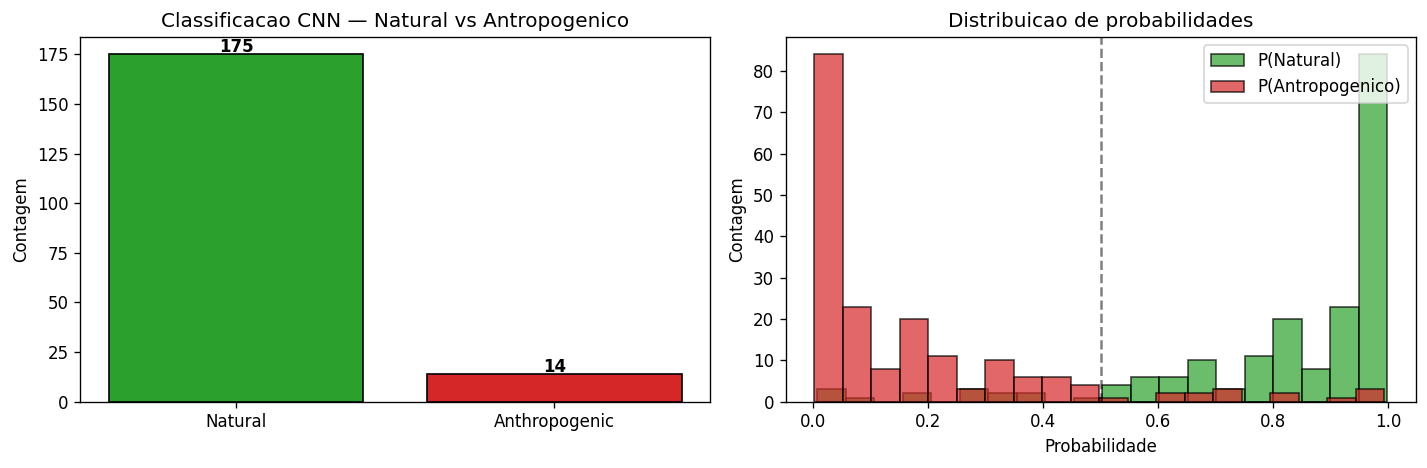

Figura salva em ../outputs/figures/step5_class_distribution.png


In [12]:
label_counts = df["event_label"].value_counts()
total = len(df)

print("Classificacao CNN:")
for label, count in label_counts.items():
    pct = 100.0 * count / total
    print(f"  {label}: {count} ({pct:.1f}%)")
print(f"  Total: {total}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}
bar_colors = [colors.get(l, "gray") for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="black")
axes[0].set_ylabel("Contagem")
axes[0].set_title("Classificacao CNN — Natural vs Antropogenico")
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 1, str(count), ha="center", fontweight="bold")

# Histograma de probabilidades
df_valid = df[df["event_prob_nat"].notna()]
axes[1].hist(df_valid["event_prob_nat"], bins=20, alpha=0.7, color="#2ca02c", label="P(Natural)", edgecolor="black")
axes[1].hist(df_valid["event_prob_ant"], bins=20, alpha=0.7, color="#d62728", label="P(Antropogenico)", edgecolor="black")
axes[1].set_xlabel("Probabilidade")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Distribuicao de probabilidades")
axes[1].legend()
axes[1].axvline(0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"Figura salva em {FIGURES_DIR / 'step5_class_distribution.png'}")

## 4. Mapa espacial de MG

In [13]:
# Carregar poligono de MG
gdf_mg = gpd.read_file(str(GPKG_PATH), layer=GPKG_LAYER)
print(f"CRS do poligono: {gdf_mg.crs}")

# Criar GeoDataFrame dos eventos
df_geo = df[df["lat"].notna() & df["lon"].notna()].copy()
geometry = [Point(lon, lat) for lon, lat in zip(df_geo["lon"], df_geo["lat"])]
gdf_events = gpd.GeoDataFrame(df_geo, geometry=geometry, crs="EPSG:4326")
if gdf_mg.crs and gdf_mg.crs != gdf_events.crs:
    gdf_events = gdf_events.to_crs(gdf_mg.crs)

print(f"eventos_no_mapa={len(gdf_events)}")

CRS do poligono: EPSG:4674
eventos_no_mapa=189


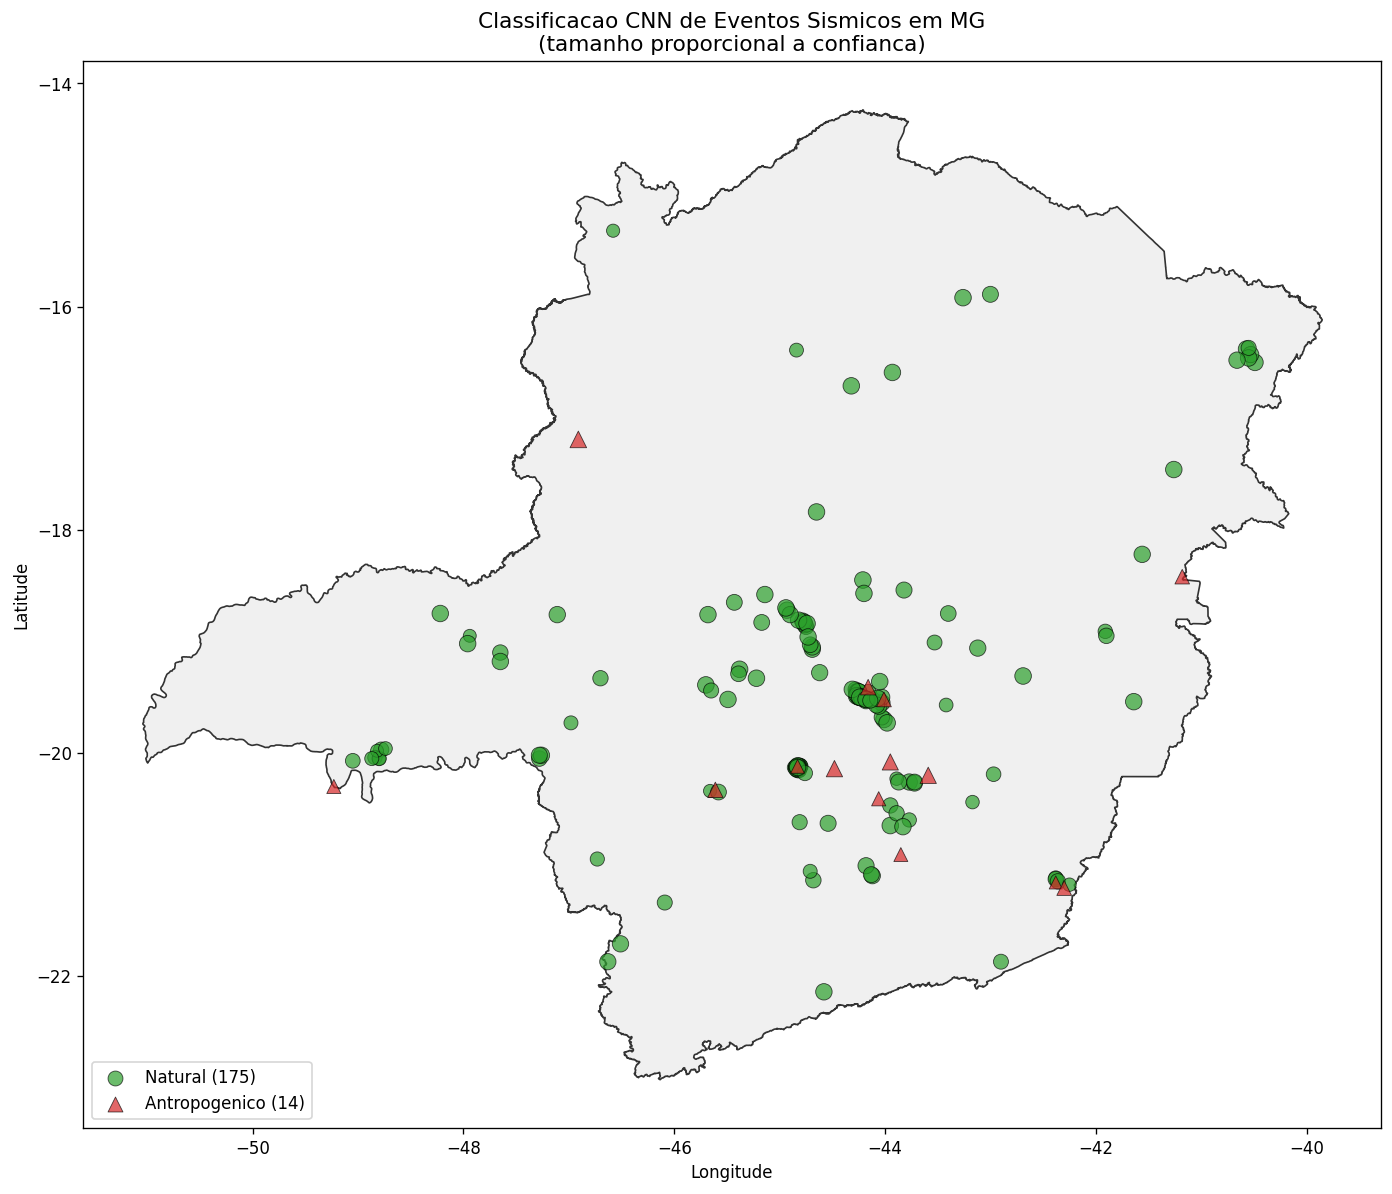

Figura salva em ../outputs/figures/step5_mapa_mg_classificacao.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

# Poligono MG
gdf_mg.plot(ax=ax, color="#f0f0f0", edgecolor="#333333", linewidth=1.0)

# Eventos Natural (verde)
nat = gdf_events[gdf_events["event_label"] == "Natural"]
ant = gdf_events[gdf_events["event_label"] == "Anthropogenic"]

# Tamanho proporcional a confianca
nat_conf = nat["event_prob_nat"].fillna(0.5).values
ant_conf = ant["event_prob_ant"].fillna(0.5).values

nat.plot(ax=ax, color="#2ca02c", edgecolor="black", linewidth=0.5,
         markersize=nat_conf * 80 + 20, alpha=0.7, label=f"Natural ({len(nat)})")
ant.plot(ax=ax, color="#d62728", edgecolor="black", linewidth=0.5,
         markersize=ant_conf * 80 + 20, alpha=0.7, marker="^", label=f"Antropogenico ({len(ant)})")

ax.set_title("Classificacao CNN de Eventos Sismicos em MG\n(tamanho proporcional a confianca)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower left", fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_mapa_mg_classificacao.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figura salva em {FIGURES_DIR / 'step5_mapa_mg_classificacao.png'}")

## 5. Analise de confianca

In [15]:
df_valid = df[df["event_prob_nat"].notna()].copy()
df_valid["confidence"] = df_valid[["event_prob_nat", "event_prob_ant"]].max(axis=1)

# Eventos de baixa confianca (prob < 0.7 para a classe vencedora)
low_conf = df_valid[df_valid["confidence"] < 0.7]
print(f"Eventos de baixa confianca (max_prob < 0.7): {len(low_conf)}")
if len(low_conf) > 0:
    print(low_conf[["event_id", "event_prob_nat", "event_prob_ant", "event_label", "confidence"]].to_string(index=False))

print(f"\nEstatisticas de confianca:")
print(f"  media={df_valid['confidence'].mean():.4f}")
print(f"  mediana={df_valid['confidence'].median():.4f}")
print(f"  min={df_valid['confidence'].min():.4f}")
print(f"  max={df_valid['confidence'].max():.4f}")

Eventos de baixa confianca (max_prob < 0.7): 31
      event_id  event_prob_nat  event_prob_ant   event_label  confidence
2020052T182035        0.674180        0.325820       Natural    0.674180
2020054T061712        0.481800        0.518200 Anthropogenic    0.518200
2020071T154829        0.566477        0.433523       Natural    0.566477
2020096T005135        0.506701        0.493299       Natural    0.506701
2020161T143154        0.689899        0.310101       Natural    0.689899
2020256T122845        0.532345        0.467655       Natural    0.532345
2020292T022117        0.660357        0.339643       Natural    0.660357
2021118T155132        0.353143        0.646857 Anthropogenic    0.646857
2022013T223033        0.651798        0.348202       Natural    0.651798
2022014T030457        0.402291        0.597709 Anthropogenic    0.597709
2022015T020750        0.693033        0.306967       Natural    0.693033
2022015T132651        0.698762        0.301238       Natural    0.698762
202

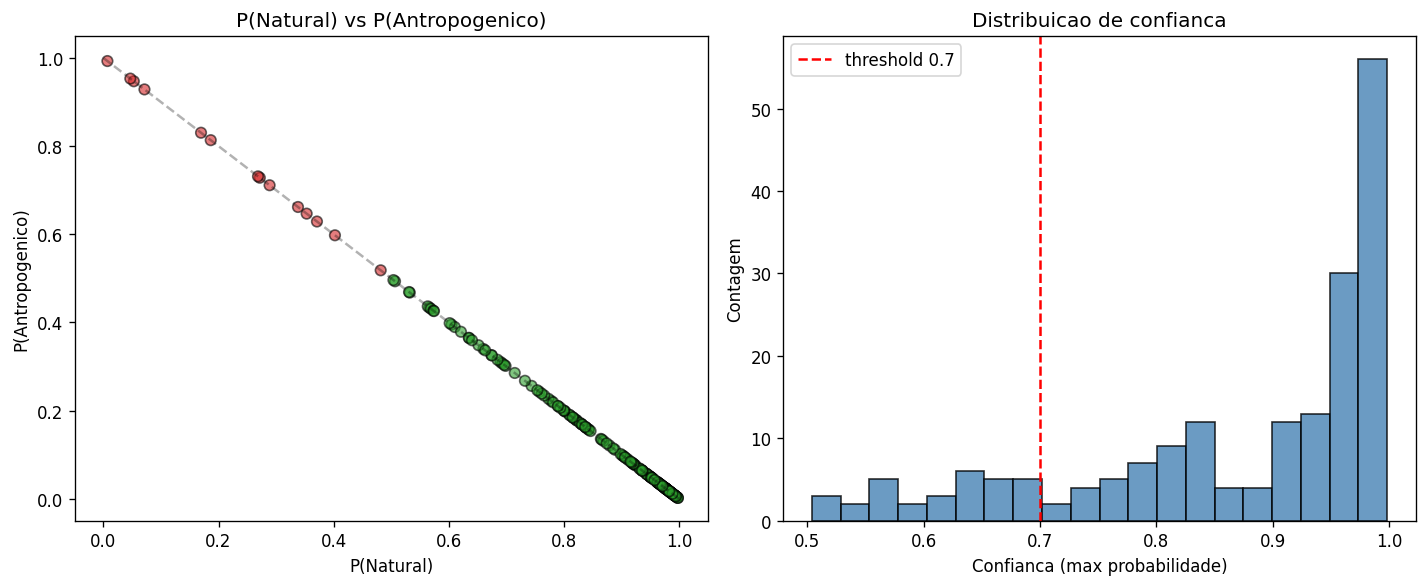

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: P(nat) vs P(ant)
c = ["#2ca02c" if l == "Natural" else "#d62728" for l in df_valid["event_label"]]
axes[0].scatter(df_valid["event_prob_nat"], df_valid["event_prob_ant"], c=c, alpha=0.6, edgecolor="black", s=40)
axes[0].plot([0, 1], [1, 0], "k--", alpha=0.3)
axes[0].set_xlabel("P(Natural)")
axes[0].set_ylabel("P(Antropogenico)")
axes[0].set_title("P(Natural) vs P(Antropogenico)")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)

# Histograma de confianca
axes[1].hist(df_valid["confidence"], bins=20, color="steelblue", edgecolor="black", alpha=0.8)
axes[1].axvline(0.7, color="red", linestyle="--", label="threshold 0.7")
axes[1].set_xlabel("Confianca (max probabilidade)")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Distribuicao de confianca")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_confidence_analysis.png", bbox_inches="tight")
plt.show()

## 6. Analise por estacao

In [17]:
# Picks por estacao
station_counts = df_picks.groupby("station").agg(
    picks_total=("status", "count"),
    picks_ok=("status", lambda x: (x == "ok").sum()),
    picks_error=("status", lambda x: x.str.startswith("error").sum()),
    picks_warning=("status", lambda x: x.str.startswith("warning").sum()),
    mean_prob_nat=("prob_nat", "mean"),
).sort_values("picks_total", ascending=False)

station_counts["error_rate"] = station_counts["picks_error"] / station_counts["picks_total"]

print(f"Estacoes unicas: {len(station_counts)}")
print(f"\nTop 15 estacoes por frequencia:")
print(station_counts.head(15).to_string())

Estacoes unicas: 28

Top 15 estacoes por frequencia:
         picks_total  picks_ok  picks_error  picks_warning  mean_prob_nat  error_rate
station                                                                              
CANS             153       151            2              0       0.851421    0.013072
DIAM             150       148            2              0       0.852820    0.013333
BSCB             142       142            0              0       0.887003    0.000000
PMNB             106       105            1              0       0.810278    0.009434
SJMB              62        62            0              0       0.859281    0.000000
IPMB              38        38            0              0       0.883289    0.000000
BB19B             31        30            1              0       0.700728    0.032258
RIB01             16        16            0              0       0.647069    0.000000
ALF01             15        15            0              0       0.829648    0.000000
V

Estacoes com erros (5):
         picks_total  picks_ok  picks_error  error_rate
station                                                
CANS             153       151            2    0.013072
DIAM             150       148            2    0.013333
PMNB             106       105            1    0.009434
BB19B             31        30            1    0.032258
JANB               6         5            1    0.166667


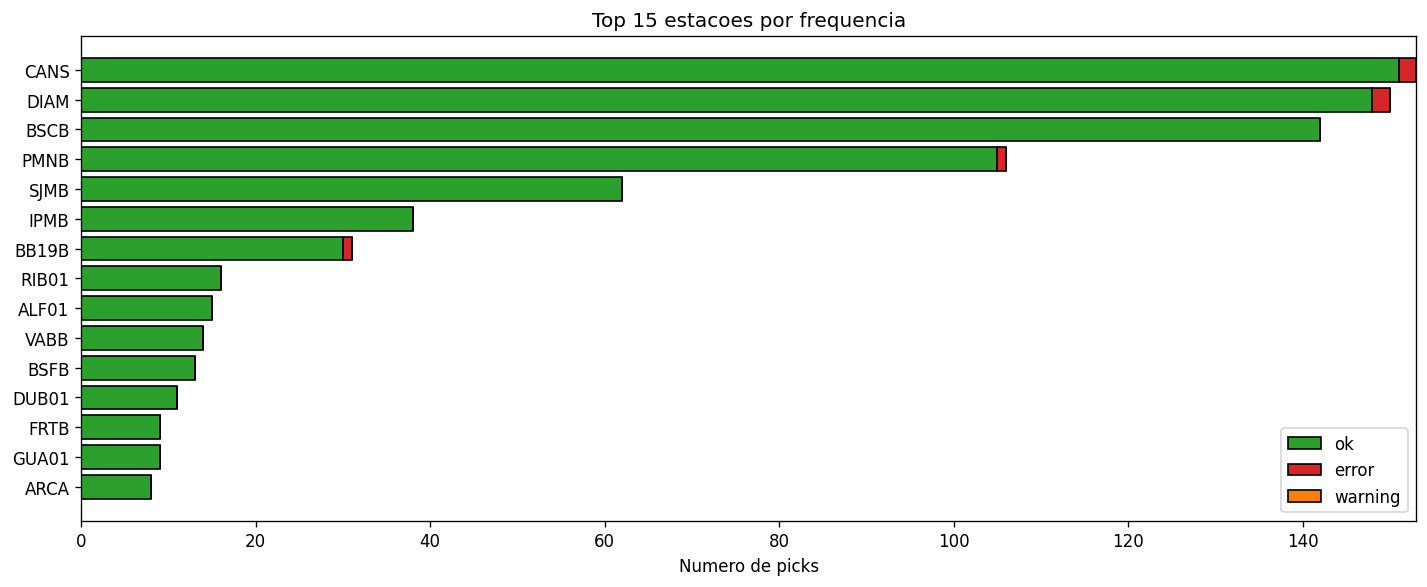

In [18]:
# Estacoes com erros
stations_with_errors = station_counts[station_counts["picks_error"] > 0]
if len(stations_with_errors) > 0:
    print(f"Estacoes com erros ({len(stations_with_errors)}):")
    print(stations_with_errors[["picks_total", "picks_ok", "picks_error", "error_rate"]].to_string())
else:
    print("Nenhuma estacao com erros.")

# Plot top 15 estacoes
top15 = station_counts.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top15.index, top15["picks_ok"], color="#2ca02c", label="ok", edgecolor="black")
ax.barh(top15.index, top15["picks_error"], left=top15["picks_ok"], color="#d62728", label="error", edgecolor="black")
ax.barh(top15.index, top15["picks_warning"], left=top15["picks_ok"] + top15["picks_error"],
        color="#ff7f0e", label="warning", edgecolor="black")
ax.set_xlabel("Numero de picks")
ax.set_title("Top 15 estacoes por frequencia")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_stations.png", bbox_inches="tight")
plt.show()

## 7. Analise temporal

In [19]:
# Extrair ano do origin_time
df_time = df[df["origin_time"].notna()].copy()
df_time["origin_dt"] = pd.to_datetime(df_time["origin_time"], errors="coerce")
df_time["year"] = df_time["origin_dt"].dt.year
df_time["month"] = df_time["origin_dt"].dt.month

# Eventos por ano
year_class = df_time.groupby(["year", "event_label"]).size().unstack(fill_value=0)
print("Eventos por ano e classe:")
print(year_class.to_string())
print(f"\nTotal por ano: {year_class.sum(axis=1).to_dict()}")

Eventos por ano e classe:
event_label  Anthropogenic  Natural
year                               
2020                     4       30
2021                     1       18
2022                     3       85
2023                     6       42

Total por ano: {2020: 34, 2021: 19, 2022: 88, 2023: 48}


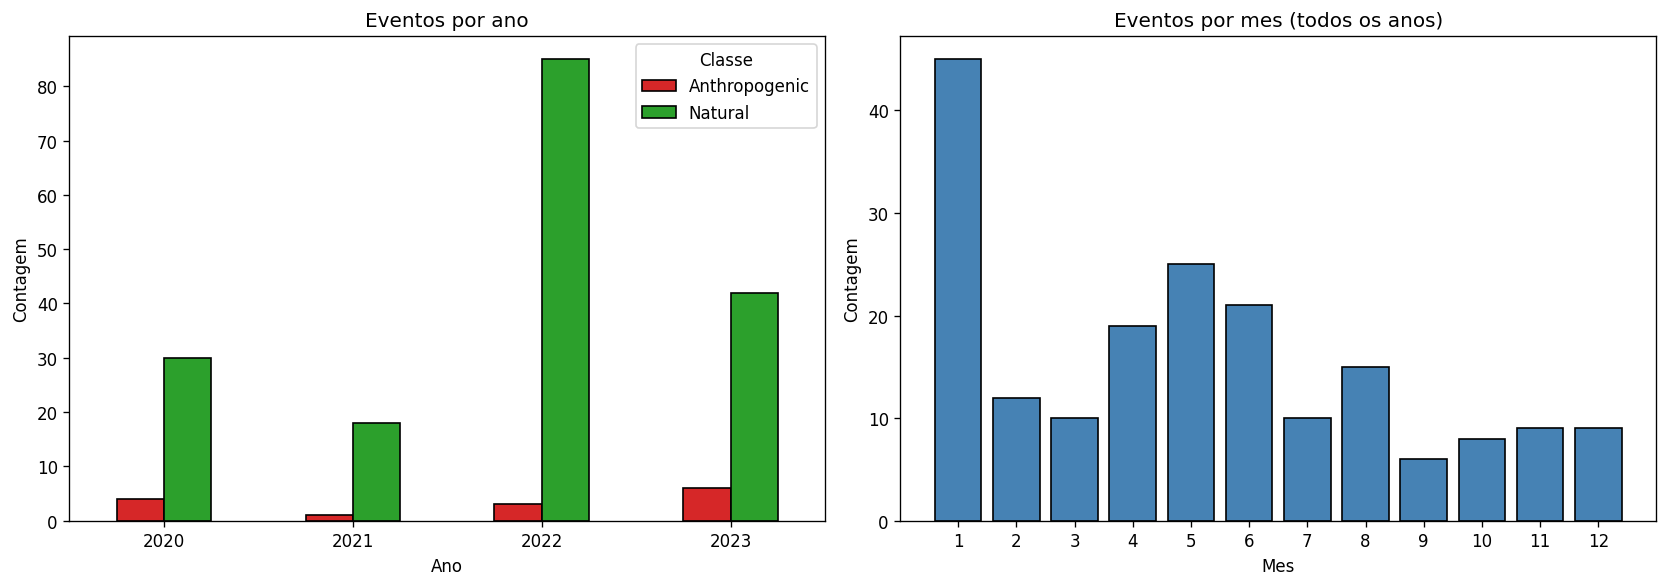

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eventos por ano colorido por classe
colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}
year_class.plot(kind="bar", ax=axes[0], color=[colors_map.get(c, "gray") for c in year_class.columns],
               edgecolor="black")
axes[0].set_title("Eventos por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Contagem")
axes[0].legend(title="Classe")
axes[0].tick_params(axis="x", rotation=0)

# Eventos por mes
month_counts = df_time.groupby("month").size()
axes[1].bar(month_counts.index, month_counts.values, color="steelblue", edgecolor="black")
axes[1].set_title("Eventos por mes (todos os anos)")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Contagem")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_temporal.png", bbox_inches="tight")
plt.show()

## 8. Detalhes dos erros de preprocessamento

In [21]:
print(f"Total de erros: {len(df_errors)}")
if len(df_errors) > 0:
    print("\nErros por tipo:")
    print(df_errors["kind"].value_counts().to_string())
    print("\nDetalhes:")
    print(df_errors[["event_id", "station", "kind", "message"]].to_string(index=False))

Total de erros: 7

Erros por tipo:
kind
error_preprocess    7

Detalhes:
      event_id station             kind                                                message
2021022T041155   BB19B error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2021022T041155    CANS error_preprocess  invalid spectrogram shape (66, 50) expected (237, 50)
2021028T105750    CANS error_preprocess invalid spectrogram shape (134, 50) expected (237, 50)
2022018T202926    PMNB error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2022150T161538    DIAM error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2023166T200008    JANB error_preprocess  invalid spectrogram shape (71, 50) expected (237, 50)
2023335T041200    DIAM error_preprocess  invalid spectrogram shape (60, 50) expected (237, 50)


## 9. Tabela final consolidada

In [22]:
# Tabela final com todos os campos relevantes
df_final = df[[
    "event_id", "status", "event_label", "event_prob_nat", "event_prob_ant",
    "picks_total", "picks_valid", "picks_error", "picks_warning",
    "lat", "lon", "magnitude", "depth_km", "origin_time"
]].copy()
df_final = df_final.sort_values("event_id")

output_csv = Path("../outputs/rnc_results_consolidated_m12v2.csv")
df_final.to_csv(output_csv, index=False)
print(f"Tabela consolidada salva em {output_csv}")
print(f"Total: {len(df_final)} eventos")
print(f"\nAmostra (primeiros 10):")
df_final.head(10)

Tabela consolidada salva em ../outputs/rnc_results_consolidated_m12v2.csv
Total: 189 eventos

Amostra (primeiros 10):


,event_id,status,event_label,event_prob_nat,event_prob_ant,picks_total,picks_valid,picks_error,picks_warning,lat,lon,magnitude,depth_km,origin_time
0,2020020T210424,ok,Natural,0.831680,0.168320,7,7,0,0,-19.10,-47.65,2.5,0.0,2020-01-20T21:04:25Z
1,2020022T221808,ok,Natural,0.974919,0.025081,8,8,0,0,-19.55,-44.03,2.8,0.0,2020-01-22T22:18:09Z
2,2020028T143723,ok,Natural,0.935955,0.064045,5,5,0,0,-19.45,-44.27,2.2,0.0,2020-01-28T14:37:23Z
3,2020030T152418,ok,Anthropogenic,0.052710,0.947290,7,7,0,0,-20.20,-43.59,2.2,0.0,2020-01-30T15:24:19Z
4,2020052T182035,ok,Natural,0.674180,0.325820,6,6,0,0,-21.12,-42.38,1.9,0.0,2020-02-21T18:20:35Z
5,2020052T190819,ok,Natural,0.822391,0.177609,6,6,0,0,-21.13,-42.38,2.2,0.0,2020-02-21T19:08:19Z
6,2020054T061712,ok,Anthropogenic,0.481800,0.518200,2,2,0,0,-21.16,-42.38,1.7,0.0,2020-02-23T06:17:12Z
7,2020056T031433,ok,Natural,0.821661,0.178339,7,7,0,0,-21.15,-42.36,1.9,0.0,2020-02-25T03:14:33Z
8,2020071T154829,ok,Natural,0.566477,0.433523,7,7,0,0,-21.18,-42.25,2.4,0.0,2020-03-11T15:48:29Z
9,2020074T122512,ok,Natural,0.949230,0.050770,3,3,0,0,-19.28,-44.62,2.6,0.0,2020-03-14T12:25:12Z


## 10. Resumo numerico final

In [23]:
print("=" * 60)
print("RESUMO FINAL — Classificacao CNN RNC sobre MG")
print("=" * 60)
print(f"Total de eventos: {len(df)}")
print(f"Eventos ok: {(df['status'] == 'ok').sum()}")
print(f"Eventos parciais: {(df['status'] == 'partial').sum()}")
print()
for label, count in df["event_label"].value_counts().items():
    pct = 100.0 * count / len(df)
    print(f"  {label}: {count} ({pct:.1f}%)")
print()
print(f"Total de picks processados: {len(df_picks)}")
print(f"Picks ok: {(df_picks['status'] == 'ok').sum()}")
print(f"Picks com erro: {df_picks['status'].str.startswith('error').sum()}")
print(f"Erros detalhados: {len(df_errors)}")
print()
print(f"Estacoes unicas: {df_picks['station'].nunique()}")
print()
print("Figuras geradas em outputs/figures/:")
for f in sorted(FIGURES_DIR.glob("step5_*.png")):
    print(f"  {f.name}")
print("=" * 60)

RESUMO FINAL — Classificacao CNN RNC sobre MG
Total de eventos: 189
Eventos ok: 183
Eventos parciais: 6

  Natural: 175 (92.6%)
  Anthropogenic: 14 (7.4%)

Total de picks processados: 821
Picks ok: 814
Picks com erro: 7
Erros detalhados: 7

Estacoes unicas: 28

Figuras geradas em outputs/figures/:
  step5_class_distribution.png
  step5_confidence_analysis.png
  step5_mapa_mg_classificacao.png
  step5_stations.png
  step5_temporal.png


## Conclusoes

1. A CNN classificou todos os 189 eventos com sucesso (183 ok, 6 parciais).
2. A grande maioria dos eventos foi classificada como Natural.
3. Os erros de preprocessamento sao exclusivamente por shape de espectrograma
   (waveforms com duracao insuficiente para gerar os 237 frames esperados).
4. Nenhum evento ficou sem classificacao — mesmo os parciais tem picks validos.
5. O mapa espacial e as figuras estao prontos para discussao com os orientadores.